# 5. Prefix Caching

By [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)) and [Claude Code](https://claude.com/claude-code) 🤖

The last three lectures treated prefill as work that has to be done: it is
compute-bound (lecture 1), it interferes with decoding (lecture 3), and we can
either chunk it or move it to its own GPUs (lecture 4). This lecture is about
how we can avoid some prefill.

## Why the same tokens arrive over and over

An LLM is a pure function of the tokens you hand it. The server keeps nothing
between requests, at least in its simplest form. So in a chatbot, where the model
must be aware of the conversation so far, the past conversation is simply
prepended to the new question: the model reads the whole history and the question
together, every time.

So a two-message chat is not two small requests. It is one small request and one
large one, and what actually goes over the wire looks like this:

```text
request 1   [system prompt, ~1,000 tokens]
            [user: "How do I reverse a list in Python?"]

response 1  [assistant: "Use list.reverse(), or ..."]

request 2   [system prompt, ~1,000 tokens]            <- identical
            [user: "How do I reverse a list in Python?"]   <- identical
            [assistant: "Use list.reverse(), or ..."]      <- identical
            [user: "What about a tuple?"]                  <- new
```

The **system prompt** is the block of text the application puts in front of every
conversation and never shows you: who the assistant is supposed to be, what it
must refuse to do, today's date, the JSON schema of every tool it may call, and
often a handful of examples of good answers. In a serious application it is not
short — several hundred to a few thousand tokens, and for an agent carrying a
dozen tool definitions, much more (lecture 6).

The first request prefills the system prompt plus the user's question. The second
prefills the system prompt, the first question, the first answer, *and* the second
question. It has to carry the first exchange because the model cannot see it
otherwise: "What about a tuple?" is meaningless without the question and the
answer above it. The prompt keeps growing like this for the rest of the
conversation — and almost all of it is text the model has already processed.

### The same text also repeats across users

Repetition is not confined to one conversation. *Every* request an LLM-based
application makes is prefixed with the same system prompt, so the opening
thousand tokens of every request are token-for-token identical, even though the
users who sent them have nothing to do with each other.

It helps to see what that text actually is. The excerpts below are decoded from
the recorded traces of [OWL](https://github.com/camel-ai/owl)
([Hu et al., NeurIPS '25](https://arxiv.org/abs/2505.23885)), the open-source
multi-agent system we take apart in lecture 6. This is verbatim what it sent to
the model, elided where marked. Every request its web-search worker makes opens
with the following **system prompt**:

```text
You are a helpful assistant that can search the web, extract webpage content,
simulate browser actions, and provide relevant information to solve the given task.
Keep in mind that:
- Do not be overly confident in your own knowledge. Searching can provide a
  broader perspective and help validate existing knowledge.
- If the search snippet is unhelpful but the URL comes from an authoritative
  source, try visit the website for more details.
- When looking for specific numerical values (e.g., dollar amounts), prioritize
  reliable sources and avoid relying only on search snippets.
- When solving tasks that require web searches, check Wikipedia first before
  exploring other websites.
[...]
```

Directly below it come the **tool definitions** — the name, description and
argument schema of each of the eight tools this worker may call. Two of them:

```text
namespace functions {

// Use Google search engine to search information for the given query.
type search_google = (_: {
// The query to be searched.
query: string,
// The number of result pages to retrieve.
num_result_pages: number,
}) => any;

// Search the entity in WikiPedia and return the summary of the required page,
// containing factual information about the given entity.
type search_wiki = (_: {
// The entity to be searched.
entity: string,
}) => any;

[... six more ...]
}
```

A different role, OWL's planner, instead carries a page of **worked examples** of
the judgement it is being asked to make — the agent's version of the few-shot
examples a classifier puts in front of every input:

```text
Here are some scenarios where using code is the preferred approach:
1. Tasks requiring access to a large number of webpages. Example: "How many times
   was a Twitter/X post cited as a reference on English Wikipedia pages for each
   day of August in the last June 2023 versions of the pages?" Reason: Manually
   checking each Wikipedia page would be highly inefficient, while Python code can
   systematically fetch and process the required data.
2. Data processing involving complex filtering or calculations. Example: "Analyze
   all article titles on Hacker News in March 2024 and find the top 10 most
   frequently occurring keywords." Reason: This task requires processing a large
   amount of text data, which is best handled programmatically.
[...]
```

Whenever the agent needs a web search, the request it sends to the web-search
worker opens with about 1,500 tokens of the text shown above, before the actual
task is even mentioned.

Common prefixes also appear when many people ask about the same document — the
same manual, contract or repository file pasted above a different question each
time. [vLLM's documentation](https://docs.vllm.ai/en/latest/features/automatic_prefix_caching/)
gives exactly that as the canonical case for turning prefix caching on.

Mooncake ([Qin et al., FAST '25](https://arxiv.org/abs/2407.00079)), the serving system behind the Kimi
chatbot, reports from its production traces that roughly half of all prompt tokens
are reusable when the cache has room — about 40% on conversational traffic, where
most of the reuse is a user's own history, and about 59% on tool- and agent-style
traffic, where those long, repetitive system prompts are reused across users. The
same deployment's hit rate falls below 20% at peak hours, when the cache does not
have room; we will reproduce that effect later in the lecture.

## The idea

**Prefix caching** keeps that KV cache — the per-token keys and values every
later token attends to (lecture 2) — around after a request finishes, and reuses
it. If a new prompt starts with a set of tokens whose KV is still around, those
tokens are not prefilled again; the model reuses the KV from the past and computes
KV only for the tokens it has never seen. It costs nothing in accuracy: the KV of a token depends only on
the tokens before it, so a reused block holds exactly the values a fresh prefill
would have produced.

:::{admonition} Learning goals
- Explain how a KV cache is addressed by block hashes, and why reuse works only
  on a *prefix*.
- Measure the effect of prefix caching on prefill work and TTFT, both within one
  conversation and across users who share a long preamble.
- Explain the two things that destroy a hit: eviction under memory pressure, and
  a request landing on a replica that does not hold the prefix.
- Lay out a prompt so that it is cache-friendly, and say what cross-user sharing
  costs as well as what it buys.
- Say where cached blocks actually live in a production deployment, and where
  these labs simplify.
:::

## Setup

Same system as lectures 3 and 4: Qwen2.5-32B-Instruct, one replica on two A100s.

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/faculty/kvm6242/.llm-systems-wo-gpus/backend


## How a prefix cache works

### Step 1: the KV cache is already paged

We have not yet looked at how the KV cache is laid out in memory. It is not one
contiguous array per request: it is stored at the granularity of **blocks** (also
called pages), which you can think of as pages in virtual memory. The idea of
storing the KV cache in blocks was introduced by **PagedAttention**
([Kwon et al., SOSP '23](https://arxiv.org/abs/2309.06180)), the paper vLLM was built around.

Block sizes can be configured: vLLM defaults to 16 tokens (`--block-size`),
TensorRT-LLM to 32, and SGLang to 1 (`--page-size`). Larger blocks mean less
bookkeeping per token and more efficient transfers when blocks move between
memories; smaller blocks waste less space in the last, partial block and — as the
next step shows — match prefixes more precisely. Our labs use 16.

### Step 2: give every block a name

Prefix caching adds one idea on top: **give every full block a name, and keep a
table from names to blocks.** The name is a hash of

```text
hash(block) = H( hash(previous block), the 16 token ids in this block )
```

so a block's name depends on its own tokens *and* on the entire history before
it. Two requests get the same name for their 5th block only if their first 80 (16$\times$5)
tokens are identical.

When a request arrives, the scheduler hashes its prompt block by block and looks
each name up, stopping at the first miss. Everything before the miss is a **hit**:
those blocks are reused (their reference count goes up, so they cannot be
evicted while in use) and the request is prefilled starting from the first
uncached token.

```text
  turn 1 prompt   [sys ][sys ][user1]                 3 blocks computed,
                                     [ans1]           1 more filled while decoding
  turn 2 prompt   [sys ][sys ][user1][ans1][user2]    4 hits, 1 block computed
```

Note that the answer's blocks are reusable too: they were written during turn 1's
decode and named like any other, which is why turn 2 reuses the previous answer
as well as the previous prompt.

Three properties follow, and all three matter in practice:

1. **Matching is on a prefix, not on a substring.** The chained hash means one
   different token early in the prompt gives every later block a different name,
   even if the rest of the text is identical. Only the run of tokens that is
   identical from the very first one counts as a hit.
2. **The last, partial block is not named.** Only full blocks are hashed, so
   hits are rounded down to a multiple of the block size. This is a small artefact
   that we will mostly ignore; it only matters when the block size is large, which
   it usually is not.
3. **Cached blocks compete for memory with running requests.** Cached prefixes and
   the KV cache of running requests sit in the same pool, so when a request needs
   more space, the server has to evict something — and the natural candidate is a
   block no running request is using, which is exactly what a cached prefix is. An
   evicted prefix cannot be reused, even when a request that matches it arrives
   later.

### The same idea, a different data structure

A flat hash table is not the only way to answer "which prefixes do I already
have". SGLang keeps them in a **radix tree** over token ids — *RadixAttention*
([Zheng et al., NeurIPS '24](https://arxiv.org/abs/2312.07104)). Each edge carries a run of tokens and the KV behind
it, a lookup is a longest-prefix walk from the root, and eviction is LRU on the
leaves. Because the tree matches token by token rather than block by block, it
does not round a hit down to a block boundary, and it makes the sharing structure
explicit: one shared system prompt is a single path near the root with a subtree
of conversations hanging off it.

The two designs are observably similar — both reuse exactly the longest matching
prefix — and the differences are in granularity, bookkeeping cost, and how
naturally eviction policies fit. The hashed-block scheme is what vLLM ships (and
enables by default in its V1 engine), and it is what our simulator implements.

### Reuse that is not a prefix

"Prefix only" is a real limitation, and the workload it hurts most is
retrieval-augmented generation: ten documents retrieved in a different order for
every user share a great deal of text and almost no prefixes. Two lines of work
relax the restriction:

- **Prompt Cache** ([Gim et al., MLSys '24](https://proceedings.mlsys.org/paper_files/paper/2024/hash/a66caa1703fe34705a4368c3014c1966-Abstract-Conference.html)) has the application declare reusable
  *segments* in a schema, precomputes each segment's attention state once, and
  re-encodes positions when a segment lands at a new offset.
- **CacheBlend** ([Yao et al., EuroSys '25](https://arxiv.org/abs/2405.16444)) concatenates the cached KV of several
  chunks and then selectively recomputes a small fraction of the tokens, to repair
  the attention those chunks never paid to each other. It reports 2–3× lower TTFT
  at what it measures as a negligible quality drop.

Both trade exactness for reuse: a block's keys and values were computed in a
context that no longer matches, so the reconstruction is an approximation rather
than the identity we got for free with prefixes. That is why strict prefix
matching is what production engines turn on by default, and why the rest of this
lecture stays with it.

### Where the cached blocks live

It is tempting to say "the KV is still in GPU memory", and in these labs that is
literally true: one pool of blocks per replica, in HBM, and an evicted block is
gone. Production systems treat HBM as only the fastest tier of a hierarchy. vLLM
can offload blocks to CPU memory; [LMCache](https://github.com/LMCache/LMCache)
adds a reusable KV store with local and remote backends; and Mooncake
([Qin et al., FAST '25](https://arxiv.org/abs/2407.00079)), which serves the Kimi chatbot, goes furthest — it pools the CPU DRAM,
SSDs and RDMA NICs of an entire GPU cluster into one disaggregated KVCache, holds
paged blocks there under LRU or LFU, and has its global scheduler send each
request to where its prefix already lives.

The arithmetic explains why anyone would build that. A token of KV cache for our
model is 256 KB (lecture 2), so a 9,000-token prefix is about 2.3 GB. Re-prefilling
it costs a second or two of GPU time (lecture 4 measured ~650 ms for 3,800
tokens); fetching it over a 25 GB/s link costs under a tenth of a second. Moving
bytes is roughly an order of magnitude cheaper than recomputing them, which is
what makes a slower, larger tier worth having. For short prefixes the comparison
flips — the transfer's fixed costs dominate — so real systems decide per request,
and that decision is itself a research area.

### What the simulator models

The strict form of the scheme above: one GPU-resident pool per replica, 16-token
blocks named by a chained hash, longest-prefix matching, LRU eviction, and nothing
below HBM. There is no CPU or SSD tier and no sharing between replicas, so every
KV cache hit rate in this lecture is what a single GPU achieves on its own. A deployment
with a CPU/SSD tier or a cluster-wide cache would do better; one that isolates
caches per tenant (see the end of the lecture) would do worse.

One practical requirement: hashing needs the actual *token ids*, so the traces in
this lecture carry a `token_ids` column, and a trace with only lengths (lectures
1–4) can never produce a hit. Prefix caching is off by default in `lsg.simulate`
and switched on with `prefix_caching=True`.

## A multi-turn workload

Let's build a trace of conversations. Each session is a user and an assistant
taking turns: a 200-token user message, a 200-token answer, then another user
message appended to everything that came before, and so on. Turn *k+1* is
released only after turn *k* finishes (`dep`), plus a **think time** standing in
for the human reading the answer.

The token ids themselves are random, which is the point: two requests share a
prefix only when we make them literally identical.

For simplicity there is no system prompt in this first workload: turn 0's prompt
is just the user's question, so the only thing two requests can share is the
history of one conversation. A shared preamble is the next experiment.

This is also a deliberately clean workload — fixed-length turns, every turn
appending to the one before, nothing matching by accident. Real conversations are
messier: turns vary in length, users edit or regenerate a message (which rewrites
the history and throws the prefix away), and clients trim old turns to fit a
context limit (which changes the *start* of the prompt, the worst place to change
anything). Read the KV cache hit rates below as the shape of the effect rather than a
number to expect; lecture 6 measures 60% on a recorded agent workload.

In [2]:
rng = np.random.default_rng(0)
def toks(n):
    """n token ids that appear nowhere else (so nothing matches by accident)."""
    return rng.integers(10, 150_000, n).tolist()

def chat_trace(n_sessions=24, n_turns=6, question=200, answer=200, preamble=0,
               preamble_first=True, think=5.0, name=None):
    """Multi-turn conversations, optionally sharing a `preamble`-token system prompt."""
    shared = toks(preamble)
    rows = []
    for s in range(n_sessions):
        context = []
        for t in range(n_turns):
            user = toks(question)
            # Turn 0 starts the conversation; later turns append to the context.
            context = (shared + user if preamble_first else user + shared) if t == 0 \
                      else context + user
            reply = toks(answer)
            rows.append(dict(prefill=len(context), decode=answer, ids=context + reply,
                             session=s, turn=t, dep=[] if t == 0 else [t - 1],
                             think=0.0 if t == 0 else think, rid=1000 * s + t))
            context = context + reply    # the next turn sees this answer too
    df = pd.DataFrame(rows)
    path = lsg.make_trace(df.prefill, df.decode, len(df), name=name, token_ids=df.ids,
                          session_id=df.session, turn_id=df.turn, dep=df.dep,
                          think_time=df.think, request_id=df.rid)
    return path, df

chat, chat_df = chat_trace()
chat_df[["session", "turn", "prefill", "decode", "think"]].head(7)

,session,turn,prefill,decode,think
0,0,0,200,200,0.0
1,0,1,600,200,5.0
2,0,2,1000,200,5.0
3,0,3,1400,200,5.0
4,0,4,1800,200,5.0
5,0,5,2200,200,5.0
6,1,0,200,200,0.0


Turn 0 prefills 200 tokens, and every later turn 400 more than the one before:
the user's new message plus the assistant's previous answer. Only those 400
tokens are new; everything else was computed on this replica seconds ago.

## Does it help?

Run the same trace with prefix caching off and on.

In [3]:
def run(trace, df, **kwargs):
    return lsg.simulate(**SYSTEM, trace=trace, num_requests=len(df), **kwargs)

cols = ["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "throughput (tok/s)",
        "total execution time (s)"]
runs = {f"prefix caching {'on' if pc else 'off'}": run(chat, chat_df, qps=1.0, prefix_caching=pc)
        for pc in (False, True)}
pd.DataFrame({k: {**r.summary()[cols], "prompt tokens computed": r.requests["request_num_prefill_tokens"].sum()
                                       - r.requests["request_num_prefill_tokens_cached"].sum(),
                  "KV cache hit rate": r.cache_hit_rate}
              for k, r in runs.items()}).round(2)

,prefix caching off,prefix caching on
TTFT p50 (ms),351.94,84.54
TTFT p99 (ms),1966.43,123.36
TPOT p50 (ms),49.08,40.22
throughput (tok/s),1738.30,1949.51
total execution time (s),115.98,103.41
prompt tokens computed,172800.00,28800.00
KV cache hit rate,0.00,0.83


83% of all prompt tokens do not need prefilling at all: their KV cache is simply
reused from an earlier turn. The median TTFT falls from about
350 ms to 85 ms, and the tail by a factor of sixteen: a cache hit removes most
of the queueing too, because the prefill it skips would otherwise have delayed
every request behind it.

TPOT improves as well, for the reason lecture 3 gave: shorter prefills mean
fewer steps that carry a big prefill chunk alongside the decodes.

The 83% comes from the shape of this workload — six turns that only ever append —
not from prefix caching itself. A real deployment's hit rate is decided by the
shape of its prompts and by how long a prefix survives in memory, which is what
the next three sections are about.

The gain is not spread evenly over the conversation. Let's look per turn.

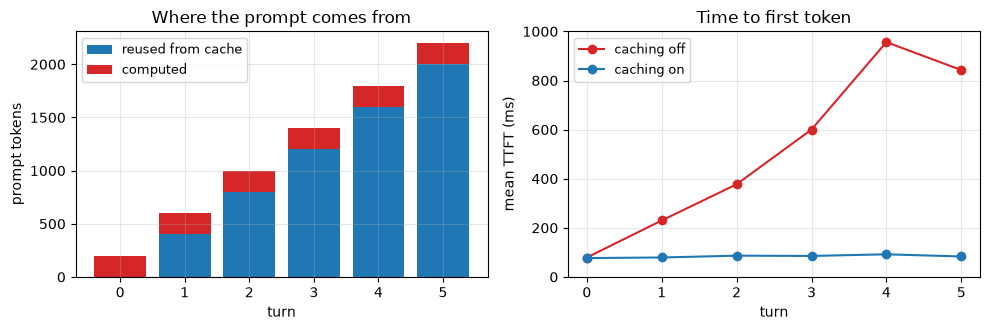

In [4]:
hit = runs["prefix caching on"].requests.copy()
hit["turn"] = hit["Request Id"] % 1000
per_turn = hit.groupby("turn").agg(prompt=("request_num_prefill_tokens", "mean"),
                                   cached=("request_num_prefill_tokens_cached", "mean"),
                                   ttft=("prefill_e2e_time", "mean"))
miss = runs["prefix caching off"].requests.copy()
miss["turn"] = miss["Request Id"] % 1000
per_turn["ttft_off"] = miss.groupby("turn")["prefill_e2e_time"].mean()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].bar(per_turn.index, per_turn["cached"], label="reused from cache", color="C0")
ax[0].bar(per_turn.index, per_turn["prompt"] - per_turn["cached"],
          bottom=per_turn["cached"], label="computed", color="C3")
ax[0].set(xlabel="turn", ylabel="prompt tokens", title="Where the prompt comes from")
ax[1].plot(per_turn.index, 1e3 * per_turn["ttft_off"], "o-", color="C3", label="caching off")
ax[1].plot(per_turn.index, 1e3 * per_turn["ttft"], "o-", color="C0", label="caching on")
ax[1].set(xlabel="turn", ylabel="mean TTFT (ms)", title="Time to first token", ylim=(0, None))
for a in ax:
    a.legend(fontsize=9)
fig.tight_layout()

Without caching, a conversation gets more expensive with every turn: the prompt
grows, so TTFT grows. With caching, the *computed* part of the prompt is flat —
always the 400 new tokens — and so is TTFT. This is the single most important
consequence of prefix caching: **the cost of a turn stops depending on how long
the conversation already is.**

(Turn 0 is the exception. Its prompt is new, so it is a full miss, and it is the
only turn whose TTFT the cache cannot improve.)

## Prompt layout: where the shared text goes

Now the cross-user case from the introduction. These 60 requests belong to 60
different users with nothing in common except the application they are talking
to — no conversation history to reuse, and the first user to arrive gets no help
from the cache at all. What they share is the preamble the application prepends:
system prompt, tool definitions, few-shot examples.

We give them a shared preamble of 0, 512, or 2,048 tokens, placed either before
the user's question or after it. The text is the same in both cases; only the
order differs.

In [5]:
layout = {}
for preamble in (0, 512, 2048):
    for first in (True, False):
        if preamble == 0 and not first:
            continue
        tr, df = chat_trace(n_sessions=60, n_turns=1, question=200, answer=100,
                            preamble=preamble, preamble_first=first)
        r = run(tr, df, qps=2.0, prefix_caching=True)
        label = f"{preamble}-token preamble" + ("" if first else ", after the question")
        layout[label] = {"prompt tokens": int(r.requests["request_num_prefill_tokens"].mean()),
                         "KV cache hit rate": r.cache_hit_rate,
                         **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)"]]}
pd.DataFrame(layout).T.round(2)

,prompt tokens,KV cache hit rate,TTFT p50 (ms),TTFT p99 (ms)
0-token preamble,200.0,0.00,78.50,104.78
512-token preamble,712.0,0.71,80.45,140.43
"512-token preamble, after the question",712.0,0.00,192.88,389.20
2048-token preamble,2248.0,0.90,84.22,322.48
"2048-token preamble, after the question",2248.0,0.00,1461.36,3726.36


With the preamble first, 90% of the prompt tokens are shared and the median TTFT
barely moves as the preamble grows from nothing to 2,048 tokens: one request pays
for the preamble and the other 59 read its KV cache. The users never interact and
the application does nothing special; two requests starting with the same tokens
is all it takes.

Move the identical text behind the user's question and the KV cache hit rate is exactly
zero. The first block already differs between users, so the chained hash gives
every later block a different name too, and a 2,048-token preamble now costs a
17× higher median TTFT than the same preamble placed first.

:::{note}
This is the practical rule for anyone *writing* prompts for a served
application: **most stable first, most variable last**. System prompt, tool
definitions, and retrieved documents that change rarely go at the top; the
user's turn goes at the bottom. A timestamp or a session id at the start of a
system prompt is enough to disable sharing between users entirely.
:::

Hosted APIs make the same rule explicit, and their details are worth knowing
because that is the deployment most readers meet first.
[Anthropic's prompt caching](https://platform.claude.com/docs/en/build-with-claude/prompt-caching),
for instance, is opt-in and manual: you place up to four `cache_control`
breakpoints, everything before a breakpoint is cached for 5 minutes by default
(1 hour as an option), a cache *write* costs more than an ordinary input token
while a *read* costs far less, and a prefix shorter than a model-dependent minimum
(512 to 4,096 tokens) is silently not cached at all. The request is rendered in a
fixed order — tool definitions, then system prompt, then the conversation — so a
frozen tool list and a stable system prompt fall naturally at the front. Other
providers match prefixes automatically, with no markup. Either way, what the
application controls is the same thing we are measuring here: what goes first.

## The cache is finite

Cached blocks live in the same pool as the KV cache of the *running* requests.
When a replica needs a block and none is free, it evicts the least recently used
cached block — a prefix someone might have come back to.

Our replica holds about 350,000 tokens of KV cache, far more than this small
workload needs, which is why nothing was evicted above. Real replicas are not so
comfortable: they run hundreds of concurrent requests with long contexts. We can
emulate that pressure by shrinking the pool with `kv_blocks` (the number of
16-token blocks) and watching a 40-session workload, whose live context is about
90,000 tokens, fit in less and less memory.

In [6]:
chat40, chat40_df = chat_trace(n_sessions=40, n_turns=6, think=10.0, name="chat40")

def cache_row(r):
    return {"KV cache hit rate": r.cache_hit_rate,
            "evictions": int(r.cache.loc[0, "evictions"]),
            **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)"]]}

# The first row is the same workload with prefix caching switched off, for reference.
rows = {"no prefix cache": cache_row(run(chat40, chat40_df, qps=2.0, prefix_caching=False))}
sizes = [3000, 4000, 5000, 6000, 7000, 8000]
sweep_rows = [cache_row(run(chat40, chat40_df, qps=2.0, prefix_caching=True, kv_blocks=b))
              for b in sizes]
rows.update({f"{b * 16:,}": row for b, row in zip(sizes, sweep_rows)})
cache_sweep = pd.DataFrame(sweep_rows, index=[b * 16 for b in sizes])
pd.DataFrame(rows).T.rename_axis("KV cache size (tokens)").round(2)

,KV cache hit rate,evictions,TTFT p50 (ms),TTFT p99 (ms)
KV cache size (tokens),,,,
no prefix cache,0.00,0.0,535.90,9254.69
"48,000",0.37,14907.0,127.32,7065.17
"64,000",0.42,10611.0,98.89,3802.96
"80,000",0.60,5338.0,91.31,2486.91
"96,000",0.83,95.0,88.33,212.01
"112,000",0.83,0.0,88.33,212.01
"128,000",0.83,0.0,88.33,212.01


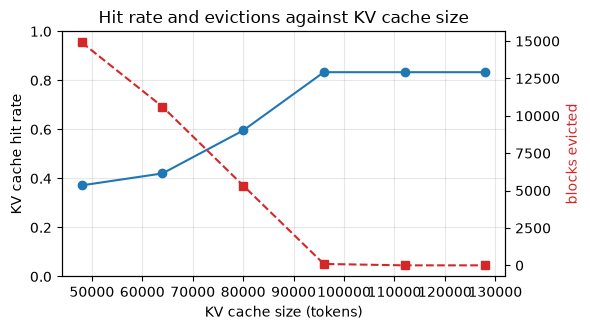

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(cache_sweep.index, cache_sweep["KV cache hit rate"], "o-", color="C0")
ax.set(xlabel="KV cache size (tokens)", ylabel="KV cache hit rate", ylim=(0, 1))
ax2 = ax.twinx()
ax2.plot(cache_sweep.index, cache_sweep["evictions"], "s--", color="C3")
ax2.set_ylabel("blocks evicted", color="C3")
ax2.grid(False)
ax.set_title("Hit rate and evictions against KV cache size")
fig.tight_layout()

Above about 96,000 tokens of KV cache — enough to hold every live session's
history — eviction all but stops and the KV cache hit rate is the full 83%. Below
it, blocks are thrown away between turns and have to be recomputed: at 48,000
tokens the hit rate has fallen to 37%, and the tail TTFT is more than thirty times
worse than at 96,000, because evicted sessions re-prefill their whole history and
preempt each other while doing it. A cramped cache is still better than none —
the median TTFT is four times lower than the no-cache row — but the tail is close
to it.

Two things about this experiment are worth separating from the result. We created
the memory pressure by shrinking the pool; a real replica gets it from serving
many long conversations at once. Different cause, same curve.

And when the pool fills, our replica simply **drops** the least recently used
cached block, so a session that returns has to prefill its whole history again.
Many production systems do not drop it — they **spill it to CPU memory or SSD**
(vLLM's offloading, LMCache, Mooncake's cluster-wide pool) and fetch it back when
the session comes back. That turns the question into a comparison of two
latencies: recompute the prefix, or fetch it from somewhere slower. For long
prefixes the fetch wins easily — the 2.3 GB behind a 9,000-token prompt takes a
second or two to recompute and well under a tenth of a second to move over a fast
link — and for short ones it does not, which is why the decision is made per
request rather than once.

## The cache is per-replica

Our replica keeps its cached blocks to itself. That is the assumption behind
every number in this section: if turn 2 of a conversation is handled by a
different replica than turn 1, the prefix is on the wrong GPU and the request is a
full miss. It is the simplest thing a cluster can do, it is what independent vLLM
or SGLang replicas behind an ordinary load balancer actually do, and it is what
the simulator models.

Real clusters sit on a spectrum above that. NVIDIA's
[Dynamo](https://github.com/ai-dynamo/dynamo) keeps the caches per replica but
puts a **KV-aware router** in front of them, scoring each replica by how much of
the incoming prompt it already holds and weighing that against how loaded it is;
the `dynamo_kv` policy below is modelled on exactly that scoring. Mooncake
([Qin et al., FAST '25](https://arxiv.org/abs/2407.00079)) removes the assumption instead: because its KVCache pool spans
the cluster's CPU memory and SSDs, a prefix computed on one GPU can be **fetched**
by another rather than recomputed, and its scheduler decides per request whether
that transfer is worth it.

So read the experiment below as the lower bound — what routing alone can do when
nothing is allowed to move. It is still the question most deployments face first,
because even a cluster that *can* move KV around would rather send the request to
where the KV already is than pay for the transfer.

Let's run the same conversations on a cluster of four replicas with different
routing policies: `round_robin` (ignore history, spread the load),
`sticky_lor` (pin each session, on its first request, to the least-loaded replica
and send every later turn of it there), and `dynamo_kv` (a Dynamo-style router
that scores each replica by the prompt tokens it would still have to compute
*plus* its current decode load).

In [8]:
routing = {}
for policy in ("round_robin", "sticky_lor", "dynamo_kv"):
    r = run(chat40, chat40_df, qps=8.0, num_replicas=4, prefix_caching=True,
            global_scheduler=policy)
    routing[policy] = {"KV cache hit rate": r.cache_hit_rate,
                       **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)", "throughput (tok/s)"]]}
pd.DataFrame(routing).T.round(2)

,KV cache hit rate,TTFT p50 (ms),TTFT p99 (ms),throughput (tok/s)
round_robin,0.39,98.58,1413.65,3226.42
sticky_lor,0.83,79.20,113.01,3291.83
dynamo_kv,0.64,93.94,1050.45,3212.77


Round-robin cuts the KV cache hit rate to less than half, and its tail TTFT is an order of
magnitude worse than the affinity-aware policies. The lesson is that prefix
caching is not purely a replica-local optimisation: **it changes what the
cluster's router should do.** Sending a request to the least-loaded replica is
the right move when every replica would have to prefill the prompt from scratch,
and the wrong one when a particular replica can skip 80% of it.

That trade-off — cache affinity against load balance — is the subject of
{doc}`08-cluster-routing`.

## What prefix caching does not do

Only prompt tokens can be reused. The answer still has to be generated one token
at a time at the memory-bound speed of lecture 1, so a workload with short prompts
and long answers gains very little from prefix caching, however repetitive its
prompts are.

Cached blocks also cost memory. A block kept for a prefix nobody comes back to is
a block the running requests cannot use, so a replica that caches too eagerly
ends up with smaller batches and less throughput. Offloading to CPU or SSD moves
that problem rather than removing it: something still has to decide which
prefixes are worth keeping and where to put them.

Skipping most of the prefill work also changes what the replica spends its time
on. Its steps now carry fewer prefill tokens, so it is more decode-dominated than
the same deployment without caching, and the chunk size (lecture 3) and
prefill:decode split (lecture 4) that were right before may not be right after.

Finally, sharing blocks between users has a consequence beyond throughput. The
preamble experiment worked because two strangers' requests touched the same
blocks, and a hit is faster than a miss in a way anyone can measure: from its own
TTFT, a request can tell whether the prefix it sent was already cached, and
therefore whether someone else sent the same text recently. This is a timing side
channel. It matters when the shared opening is not public — a tenant's
confidential system prompt, or a document pasted above a question — and the usual
answer is to give each tenant its own cache namespace and share only text that
has been declared public, at some cost in hit rate.

## What is realistic here, and what is not

The labs in this lecture are small on purpose, and a few of their simplifications
would change the numbers in a real deployment. Worth having in mind before you
quote any of them:

| | In these labs | In a production deployment |
|---|---|---|
| Block size | 16 tokens | 16 in vLLM, 32 in TensorRT-LLM, token-granular in SGLang |
| Matching | exact longest prefix, chained block hashes | the same in every major engine; research systems also reuse non-prefix segments |
| Where blocks live | one GPU pool per replica, nothing below it | HBM, then CPU DRAM, then SSD, sometimes pooled across the whole cluster |
| Losing a block | evicted and gone, so a miss costs a full re-prefill | usually demoted a tier, so a miss costs a transfer; hosted APIs also expire entries on a timer |
| Sharing | anything with a matching prefix, including across users | the same by default, isolated per tenant where that matters |
| Conversations | fixed-length turns, strictly append-only | variable, edited, regenerated, trimmed to a context limit |
| Prompts | random token ids, so sharing is exactly what we arrange | real text, where a stray timestamp decides everything |

What does carry over is the mechanism and the direction of every effect: which
tokens can be reused, what destroys a hit, and which knobs trade one against
another.

## Summary

| | Effect |
|---|---|
| What is reused | KV blocks of a matching **prefix**, named by a chained hash of their tokens |
| Biggest win | later turns of one conversation, and long openings (system prompt, tool definitions, pasted documents) shared across *different* users |
| Who shares | any two requests starting with the same tokens, whether or not they belong to the same user |
| Effect on TTFT | the computed part of the prompt stops growing with the conversation |
| Effect on TPOT / decode | indirect only (fewer and shorter prefill chunks per step) |
| Killed by | variable text placed before shared text; eviction under memory pressure; routing to another replica |
| Interacts with | router policy (affinity vs. load), chunk size, KV-cache capacity |

## Exercises

:::{admonition} Try it
:class: exercise
Each exercise asks you to change code above and rerun it. Write down your
prediction *before* you run.

1. **How much more load can the replica take?** 83% of the prompt tokens
   disappear, but prefill is only one part of the work. Sweep `qps` from 1 to 8 on
   `chat40` with caching off and on, and for each find the highest arrival rate
   that keeps p99 TTFT under 2 s (the goodput idea from lecture 2). Is the
   improvement anywhere near 83%? Account for the gap.
2. **Block granularity.** `chat_trace` writes `block_size=16`, vLLM's default.
   Rebuild the trace at 32 (TensorRT-LLM's) and at an exaggerated 256, and compare
   hit rates. Which workload loses more from coarse blocks: the multi-turn one or
   the shared-preamble one? Why would anyone still want a larger block, given
   what the lecture said about moving blocks between memory tiers?
3. **A noisy neighbour.** Add to `chat40` a handful of extra sessions whose
   prompts are long (3,000 tokens) and share nothing with anything else, as a
   second tenant would. Run the mixture at `kv_blocks=6000`, where the 40
   conversations on their own had almost no evictions. How much hit rate do the
   ordinary conversations lose, and how few noisy sessions does it take to matter?
   What does that say about serving several tenants from one replica?
4. **Does caching change the best chunk size?** Repeat lecture 3's `chunk_size`
   sweep (128, 512, 2048) on `chat40` with caching off and on. Does the best
   chunk size move?
:::

## Check your understanding

Click an answer to check it. Wrong answers can be retried.

In [9]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "Why is the KV cache split into fixed-size blocks instead of one contiguous array per request?",
     "options": ["To make the block hashes cheaper to compute",
                 "Because a request's length is not known in advance, so a contiguous reservation has to be sized for the worst case and most of it is then wasted",
                 "Because a GPU cannot address more than 16 tokens at a time"],
     "answer": 1,
     "explain": "This is PagedAttention (<a href=\"https://arxiv.org/abs/2309.06180\">Kwon et al., SOSP '23</a>): blocks need not be adjacent, so a request over-allocates by at most one block. Giving those blocks names is what makes prefix reuse possible on top of it."},
    {"q": "Why does reusing a cached KV block not change the model's output?",
     "options": ["The error is small enough to ignore",
                 "A token's keys and values depend only on the tokens before it, so the cached values are exactly what a fresh prefill would compute",
                 "The cache is only used for tokens the model has already answered about"],
     "answer": 1,
     "explain": "Attention is causal: the KV of token i is a function of tokens 0..i. If the prefix is identical, the KV is identical."},
    {"q": "Two prompts are identical except for a session id in the <b>first</b> 10 tokens. How much do they share in the cache?",
     "options": ["Everything after the session id", "Nothing", "Half"], "answer": 1,
     "explain": "A block's hash chains in the hash of the previous block, so a difference anywhere early gives every later block a different name."},
    {"q": "In the multi-turn experiment, which turn benefits least from prefix caching?",
     "options": ["The first turn", "The last turn", "All turns benefit equally"], "answer": 0,
     "explain": "Turn 0's prompt has never been seen, so it is a full miss. Later turns reuse everything up to the previous answer."},
    {"q": "An application puts a timestamp at the top of its system prompt. What is the likely effect?",
     "options": ["Nothing; the timestamp is tiny",
                 "The KV cache hit rate across users collapses, because the shared text that follows now hashes differently for every request",
                 "TPOT gets worse"],
     "answer": 1,
     "explain": "Size is irrelevant: it is position that matters. Variable text at the top invalidates the prefix for everything after it."},
    {"q": "Why did the KV cache hit rate fall when we shrank the KV cache?",
     "options": ["Smaller caches hash blocks differently",
                 "Cached blocks are evicted to make room for running requests, so a returning turn no longer finds its prefix",
                 "Prefix caching turns itself off below a memory threshold"],
     "answer": 1,
     "explain": "Cached prefixes and live requests share one pool. Under pressure the least recently used cached blocks are evicted, and the next turn has to recompute them."},
    {"q": "Why does round-robin routing lower the KV cache hit rate in a multi-replica cluster?",
     "options": ["It overloads one replica",
                 "Each replica has its own KV cache, so a turn routed elsewhere cannot see the prefix its session built",
                 "It disables prefix caching"],
     "answer": 1,
     "explain": "With a cache per replica, a session has to come back to the GPU that holds its history, which is what affinity-aware routing arranges. Clusters with a shared KV store (Mooncake) can instead fetch the prefix across the network."},
    {"q": "Why do production systems keep evicted KV blocks in CPU memory or on SSD instead of dropping them?",
     "options": ["To survive a GPU crash",
                 "Because fetching a prefix back is roughly an order of magnitude cheaper than prefilling it again",
                 "Because CPU memory is faster than HBM"],
     "answer": 1,
     "explain": "A 9,000-token prefix is ~2.3 GB here: a second or two to recompute, under a tenth of a second to transfer. For short prefixes the comparison flips, which is why the decision is made per request."},
    {"q": "A RAG application retrieves the same ten documents for two users, but in a different order. How much does strict prefix caching reuse?",
     "options": ["All ten documents", "Only up to the first document that differs", "Nothing, ever"],
     "answer": 1,
     "explain": "Prefix matching stops at the first difference, so a reordering destroys almost all of it. Systems like Prompt Cache and CacheBlend relax this, at the price of approximating the attention the chunks never paid to each other."},
    {"q": "A workload has 200-token prompts and 2,000-token answers. How much should prefix caching help?",
     "options": ["A lot: 2,200 tokens are cached",
                 "Very little: almost all the work is decode, which prefix caching cannot skip"],
     "answer": 1,
     "explain": "Only prompt tokens can be reused. Prefix caching pays off when prompts are long and repetitive, which is exactly the agentic workload of the next lecture."},
])